In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import datetime as dt
import pandas as pd
import yfinance as yf

In [42]:
years = 15

endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*years)

In [43]:
tickers = ['SPY', 'GLD', 'BND', 'QQQ', 'VTI']

In [44]:
adj_close = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start=startDate, end=endDate)
    adj_close[ticker] = data['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [45]:
log_returns = np.log(adj_close / adj_close.shift(1))
log_returns = log_returns.dropna()
log_returns

,SPY,GLD,BND,QQQ,VTI
Date,,,,,
2011-03-30,0.006878,0.003323,0.001749,0.004719,0.007450
2011-03-31,-0.001357,0.008545,-0.001124,0.001394,0.000000
2011-04-01,0.004215,-0.004730,0.001228,0.000523,0.004791
2011-04-04,0.000825,0.004587,0.001251,-0.003312,0.000868
2011-04-05,-0.000150,0.015680,-0.002254,-0.002622,0.000579
...,...,...,...,...,...
2026-03-18,-0.014052,-0.032148,-0.004063,-0.014038,-0.013860
2026-03-19,-0.002467,-0.042088,0.001085,-0.003165,-0.001781
2026-03-20,-0.014440,-0.031034,-0.008031,-0.018655,-0.015795


In [46]:
def expected_return(weights, log_returns):
    return np.sum(weights * log_returns.mean())

In [47]:
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

In [48]:
cov_matrix = log_returns.cov()

In [49]:
portfolio_value = 1000000
weights = np.array([1/len(tickers)] * len(tickers))
portfolio_expected_return = expected_return(weights, log_returns)
portfolio_std_dev = standard_deviation(weights, cov_matrix)

In [50]:
def random_z_score():
    return np.random.normal(0, 1)

In [51]:
days = 5

def scenario_gain_loss(portfolio_value, portfolio_expected_return, portfolio_std_dev, days):
    return portfolio_value * days * portfolio_expected_return + z_score * portfolio_std_dev * np.sqrt(days)*portfolio_value

In [52]:
simulations = 10000
scenario_return = []

for i in range(simulations):
    z_score = random_z_score()
    scenario_return.append(scenario_gain_loss(portfolio_value, portfolio_expected_return, portfolio_std_dev, days))

In [53]:
confidence_interval = 0.99
Var = -np.percentile(scenario_return, (1 - confidence_interval) * 100)
print(Var)

36749.797667342384


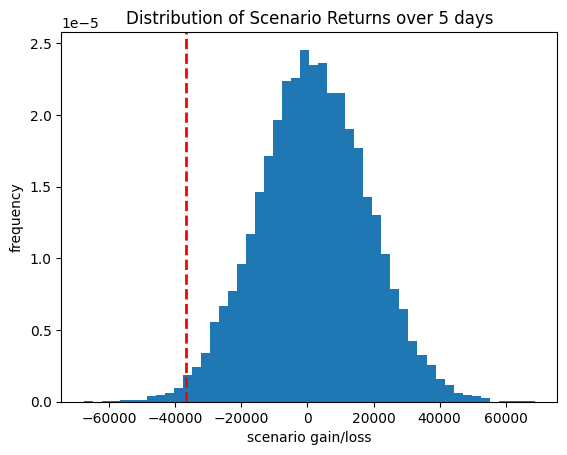

In [54]:
plt.hist(scenario_return, bins=50, density=True)
plt.xlabel('scenario gain/loss')
plt.ylabel('frequency')
plt.title(f'Distribution of Scenario Returns over {days} days')
plt.axvline(-Var, color='red', linestyle='dashed', linewidth=2, label=f'VaR at {confidence_interval*100}% confidence')
plt.show()
